<a href="https://colab.research.google.com/github/shamitha067/shamitha_codebooster_2026/blob/main/Day2/Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully")
print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.sqlite_version}")

All libraries imported successfully
pandas version: 2.2.2
sqlite3 version: 3.37.2


In [2]:
df = pd.read_csv('student_performance.csv')
print(f"Dataset loaded: {df.shape[0]} students, {df.shape}")

Dataset loaded: 30 students, (30, 13)


In [3]:
selected_columns_df = df[['student_id', 'name', 'department', 'math_score']]
display(selected_columns_df.head())

,student_id,name,department,math_score
0,1001,Aarav Sharma,Computer Science,85
1,1002,Priya Patel,Computer Science,76
2,1003,Rohit Verma,Electronics,65
3,1004,Sneha Reddy,Mechanical,70
4,1005,Arjun Nair,Computer Science,92


In [4]:
conn = sqlite3.connect(':memory:')
selected_columns_df.to_sql('students', conn, index=False, if_exists='replace')

30

In [5]:
sql_query = "SELECT student_id, name, department, math_score FROM students"
sql_result_df = pd.read_sql_query(sql_query, conn)
display(sql_result_df.head())

,student_id,name,department,math_score
0,1001,Aarav Sharma,Computer Science,85
1,1002,Priya Patel,Computer Science,76
2,1003,Rohit Verma,Electronics,65
3,1004,Sneha Reddy,Mechanical,70
4,1005,Arjun Nair,Computer Science,92


In [6]:
conn = sqlite3.connect('internship.db')
# Write the df DataFrame to a SQL table named 'students' in internship.db
df.to_sql('students', conn, index=False, if_exists='replace')

cursor = conn.cursor()

query = "SELECT student_id , name , age FROM students LIMIT 10"
data = pd.read_sql(query,conn)
print("=== DataBase Connected Successfully ===")
print(data)
conn.close()

=== DataBase Connected Successfully ===
   student_id          name  age
0        1001  Aarav Sharma   19
1        1002   Priya Patel   20
2        1003   Rohit Verma   19
3        1004   Sneha Reddy   20
4        1005    Arjun Nair   19
5        1006   Meera Joshi   20
6        1007   Kiran Kumar   21
7        1008   Divya Singh   19
8        1009  Rahul Mishra   20
9        1010    Ananya Das   19


In [7]:
conn = sqlite3.connect('internship.db')
query_top_scorers = "SELECT name,department,math_score FROM students ORDER BY math_score DESC LIMIT 5"
top_scorers_df = pd.read_sql(query_top_scorers, conn)
print("Top 5 Math Scorers:")
print(top_scorers_df)
conn.close()

Top 5 Math Scorers:
             name        department  math_score
0      Ananya Das  Computer Science          95
1     Tanvi Mehta  Computer Science          93
2      Arjun Nair  Computer Science          92
3  Akanksha Yadav  Computer Science          91
4  Swati Kulkarni  Computer Science          90


In [8]:
conn = sqlite3.connect('internship.db')
query_cs_students = "SELECT name, math_score, science_score, programming_score, attendance_percentage FROM students WHERE department = 'Computer Science' ORDER BY math_score DESC"
cs_students_df = pd.read_sql(query_cs_students, conn)
print("Computer Science Students' Performance (Ordered by Math Score Descending):")
print(cs_students_df)
conn.close()

Computer Science Students' Performance (Ordered by Math Score Descending):
              name  math_score  science_score  programming_score  \
0       Ananya Das          95             89                 97   
1      Tanvi Mehta          93             90                 96   
2       Arjun Nair          92             88                 95   
3   Akanksha Yadav          91             93                 94   
4   Swati Kulkarni          90             87                 92   
5      Divya Singh          88             91                 93   
6        Amit Bose          86             82                 89   
7     Aarav Sharma          85             78                 91   
8    Gaurav Shukla          84             79                 87   
9       Suresh Rao          83             86                 88   
10    Nisha Kapoor          79             84                 83   
11     Priya Patel          76             82                 79   
12     Ajay Tiwari          71           

In [9]:
conn = sqlite3.connect('internship.db')
query_high_attendance = "SELECT name, department, attendance_percentage FROM students WHERE attendance_percentage > 90 AND department != 'Civil' ORDER BY attendance_percentage DESC"
high_attendance_df = pd.read_sql(query_high_attendance, conn)
print("Students with high attendance (above 90%) excluding Civil department:")
print(high_attendance_df)
conn.close()

Students with high attendance (above 90%) excluding Civil department:
             name        department  attendance_percentage
0      Ananya Das  Computer Science                     98
1     Tanvi Mehta  Computer Science                     97
2     Divya Singh  Computer Science                     96
3     Sneha Reddy        Mechanical                     95
4  Akanksha Yadav  Computer Science                     95
5  Swati Kulkarni  Computer Science                     94
6    Ritu Agarwal       Electronics                     93
7    Aarav Sharma  Computer Science                     92
8   Kavya Nambiar        Mechanical                     91
9       Amit Bose  Computer Science                     91


In [10]:
conn = sqlite3.connect('internship.db')
query_high_attendance = "SELECT name, department, attendance_percentage FROM students WHERE attendance_percentage > 93 AND department NOT IN ('Mechanical') ORDER BY attendance_percentage DESC"
high_attendance_df = pd.read_sql(query_high_attendance, conn)
print("Students with high attendance (above 90%) excluding Mechanical departments:")
print(high_attendance_df)
conn.close()

Students with high attendance (above 90%) excluding Mechanical departments:
             name        department  attendance_percentage
0      Ananya Das  Computer Science                     98
1     Tanvi Mehta  Computer Science                     97
2     Divya Singh  Computer Science                     96
3  Akanksha Yadav  Computer Science                     95
4  Swati Kulkarni  Computer Science                     94


In [11]:
conn = sqlite3.connect('internship.db')
query_name_range = "SELECT name, department, math_score FROM students WHERE name BETWEEN 'A' AND 'G' ORDER BY name ASC"
students_a_to_f_df = pd.read_sql(query_name_range, conn)
print("Students with names starting from A to F:")
print(students_a_to_f_df)
conn.close()

Students with names starting from A to F:
             name        department  math_score
0    Aarav Sharma  Computer Science          85
1     Ajay Tiwari  Computer Science          71
2  Akanksha Yadav  Computer Science          91
3       Amit Bose  Computer Science          86
4      Ananya Das  Computer Science          95
5      Arjun Nair  Computer Science          92
6  Deepak Chauhan        Mechanical          68
7     Divya Singh  Computer Science          88


In [12]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('internship.db')
sql_query = """
SELECT
    department,
    COUNT(*) AS num_students,
    ROUND(AVG(math_score), 2) AS avg_math,
    ROUND(AVG(science_score), 2) AS avg_science,
    ROUND(AVG(programming_score), 2) AS avg_programming,
    ROUND(AVG(attendance_percentage), 2) AS avg_attendance
FROM students
GROUP BY department
ORDER BY num_students DESC;
"""

department_summary_df = pd.read_sql(sql_query, conn)
print("Department-wise Summary:")
print(department_summary_df)
conn.close()


Department-wise Summary:
         department  num_students  avg_math  avg_science  avg_programming  \
0  Computer Science            13     85.62        84.46            89.23   
1        Mechanical             6     71.00        76.50            49.33   
2       Electronics             6     71.00        74.17            61.50   
3             Civil             5     63.40        66.60            40.60   

   avg_attendance  
0           90.69  
1           83.50  
2           80.33  
3           74.60  


In [13]:
conn = sqlite3.connect('internship.db')

sql_query_gender_performance = """
SELECT
    gender,
    COUNT(*) AS num_students,
    ROUND(AVG(math_score), 2) AS avg_math,
    ROUND(AVG(programming_score), 2) AS avg_programming,
    ROUND(AVG(attendance_percentage), 2) AS avg_attendance
FROM students
GROUP BY gender
ORDER BY gender ASC;
"""

gender_performance_df = pd.read_sql(sql_query_gender_performance, conn)
print("Gender-wise Performance Analysis:")
print(gender_performance_df)
conn.close()

Gender-wise Performance Analysis:
   gender  num_students  avg_math  avg_programming  avg_attendance
0  Female            15     78.47             70.2           88.53
1    Male            15     73.67             65.0           80.47


In [14]:
conn = sqlite3.connect('internship.db')
cursor = conn.cursor()
chart_sql = """
SELECT department , ROUND(AVG(math_score)) AS  avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
data = pd.read_sql(chart_sql,conn)
conn.close()
print("=== DataBase Connected Successfully ===")
print("")
print(data)
conn.close()

=== DataBase Connected Successfully ===

         department  avg_math
0  Computer Science      86.0
1        Mechanical      71.0
2       Electronics      71.0
3             Civil      63.0


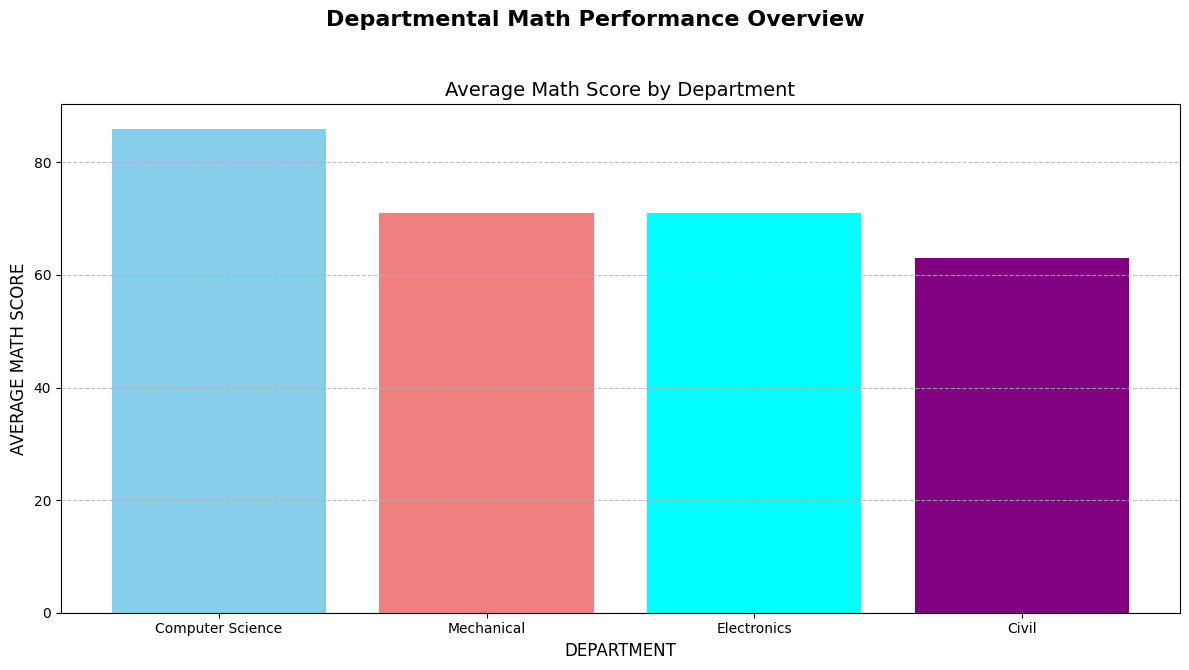

In [15]:
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['skyblue', 'lightcoral', 'cyan', 'purple']

plt.suptitle("Departmental Math Performance Overview", fontsize=16, fontweight='bold') # Overall title
plt.xlabel("DEPARTMENT", fontsize=12)
plt.ylabel("AVERAGE MATH SCORE", fontsize=12)
plt.title("Average Math Score by Department", fontsize=14)
ax.bar(data['department'], data['avg_math'], color=colors)
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [16]:
import matplotlib.pyplot as plt
import sqlite3

conn = sqlite3.connect('internship.db')
cursor = conn.cursor()
chart_sql = """
SELECT department , AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department
ORDER BY avg_attendance DESC
"""
data = pd.read_sql(chart_sql,conn)
print("=== DataBase Connected Successfully ===")
print("")
print(data)
conn.close()

=== DataBase Connected Successfully ===

         department  avg_attendance
0  Computer Science       90.692308
1        Mechanical       83.500000
2       Electronics       80.333333
3             Civil       74.600000


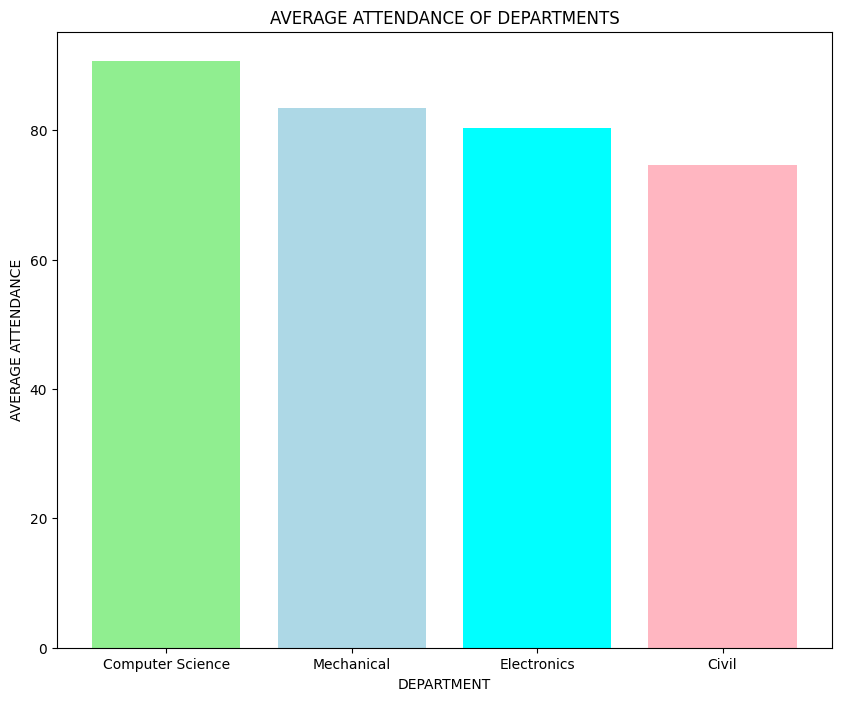

In [17]:
fig , ax = plt.subplots(figsize=(10,8))
plt.title("AVERAGE ATTENDANCE OF DEPARTMENTS")
plt.xlabel("DEPARTMENT")
plt.ylabel("AVERAGE ATTENDANCE")
plt.bar(data['department'],data['avg_attendance'], color = ['lightgreen','lightblue','cyan','lightpink'])
plt.show()

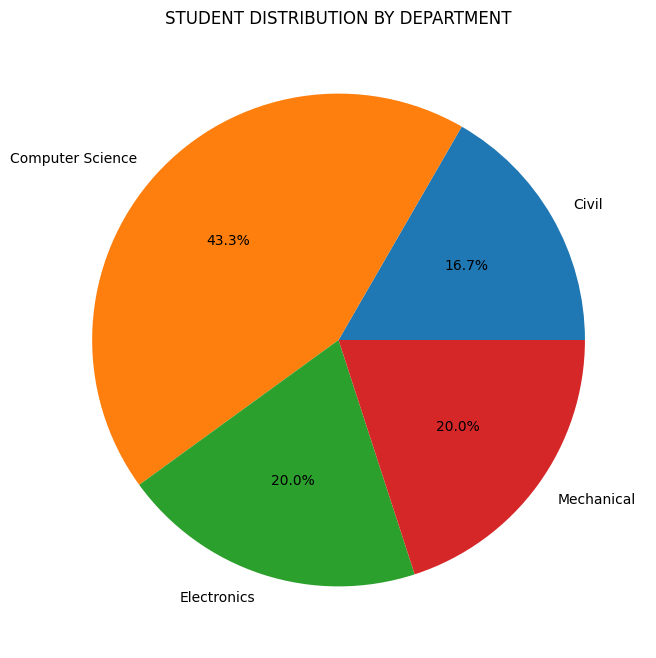

In [18]:
import sqlite3 as sql
import pandas as pd
import matplotlib.pyplot as plt

# Connect database
conn = sql.connect('internship.db') # Changed to internship.db

# SQL query
chart_sql = """
SELECT department, COUNT(student_id) AS student_count
FROM students
GROUP BY department
"""

# Read data
department_data = pd.read_sql_query(chart_sql, conn)

# Close connection
conn.close()

# Create pie chart
fig, ax = plt.subplots(figsize=(8,8))

ax.pie(
    department_data['student_count'],
    labels=department_data['department'],
    autopct='%1.1f%%'
)

# Title
ax.set_title("STUDENT DISTRIBUTION BY DEPARTMENT")

# Show chart
plt.show()

In [19]:
import matplotlib.pyplot as plt
conn = sql.connect('internship.db')
cursor = conn.cursor()
chart_sql = """
SELECT gender , ROUND(AVG(programming_score)) AS avg_programming_score
FROM students
WHERE gender = "Female"
GROUP BY gender
ORDER BY avg_programming_score DESC
"""
data = pd.read_sql(chart_sql,conn)
print("=== DataBase Connected Successfully ===")
print("")
print(data)
conn.close()

=== DataBase Connected Successfully ===

   gender  avg_programming_score
0  Female                   70.0


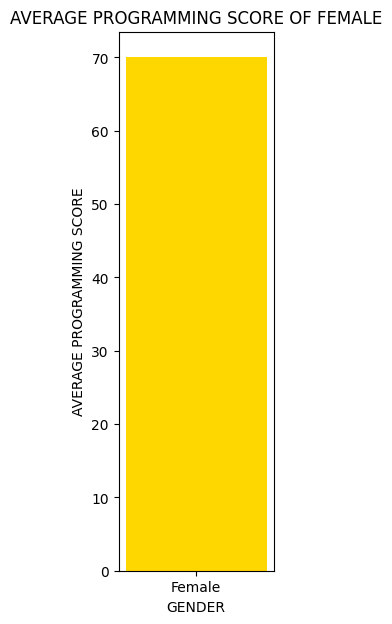

In [20]:
fig , ax = plt.subplots(figsize=(2,7))
plt.title("AVERAGE PROGRAMMING SCORE OF FEMALE")
plt.xlabel("GENDER")
plt.ylabel("AVERAGE PROGRAMMING SCORE")
plt.bar(data['gender'],data['avg_programming_score'], color = ['gold'])
plt.show()

In [21]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('internship.db')

sql_query = """
SELECT AVG(programming_score) AS average_programming_score
FROM students
WHERE gender = 'Female';
"""

result_df = pd.read_sql(sql_query, conn)
conn.close()

print(result_df)

   average_programming_score
0                       70.2


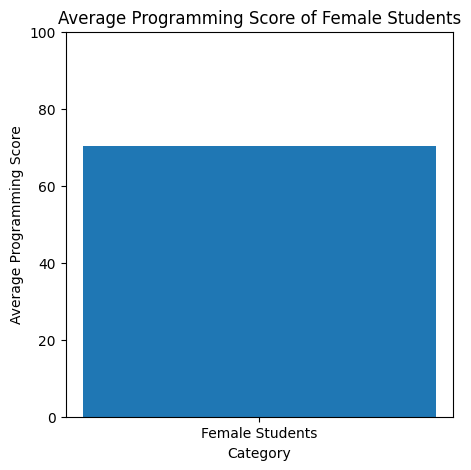

In [22]:
import matplotlib.pyplot as plt

# Average programming score of female students
female_avg = df[df['gender'] == 'Female']['programming_score'].mean()

# Create bar chart
plt.figure(figsize=(5,5))

plt.bar(['Female Students'], [female_avg])

# Labels and title
plt.xlabel("Category")
plt.ylabel("Average Programming Score")
plt.title("Average Programming Score of Female Students")

plt.ylim(0, 100)

plt.show()

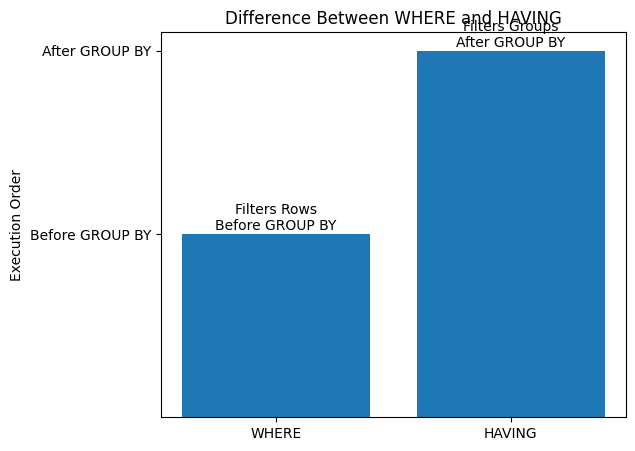

In [23]:
import matplotlib.pyplot as plt

# Data
concepts = ['WHERE', 'HAVING']
values = [1, 2]

# Create bar chart
plt.figure(figsize=(6,5))

plt.bar(concepts, values)

# Labels
plt.ylabel("Execution Order")
plt.title("Difference Between WHERE and HAVING")

# Text labels
plt.text(0, 1.02, "Filters Rows\nBefore GROUP BY", ha='center')
plt.text(1, 2.02, "Filters Groups\nAfter GROUP BY", ha='center')

plt.yticks([1, 2], ['Before GROUP BY', 'After GROUP BY'])

plt.show()